# 06_patch_feature_visualization

Phân tích và trực quan hóa đặc trưng patch từ ảnh X-ray sử dụng CNN features và t-SNE/PCA.

## 1. Import Libraries

In [3]:
import torch
# import torchvision

print("Torch version:", torch.__version__)
# print("Torchvision version:", torchvision.__version__)

Torch version: 2.1.0+cu121


In [4]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import random

# Deep Learning
import torch
import torch.nn as nn
from torchvision import models, transforms

# Dimensionality reduction
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Set random seed
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

## 2. Load Data

In [5]:
DATA_DIR = r"G:\My Drive\NCKH\A3Net-main\data\iu_xray"
IMAGE_DIR = os.path.join(DATA_DIR, "images")
ANN_PATH = os.path.join(DATA_DIR, "annotation.json")

with open(ANN_PATH, 'r') as f:
    data = json.load(f)

print("Keys:", data.keys())
print("Train:", len(data['train']))
print("Val:", len(data['val']))
print("Test:", len(data['test']))

Keys: dict_keys(['train', 'val', 'test'])
Train: 2069
Val: 296
Test: 590


## 3. Setup Feature Extractor (ResNet18)

In [6]:
# Use pretrained ResNet18 as feature extractor
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load pretrained ResNet18
resnet = models.resnet18(pretrained=True)

# Remove the final classification layer
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# Image transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

Using device: cuda


c:\Windows\System32\xray_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Windows\System32\xray_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 4. Extract Features from Images

In [7]:
def extract_features(image_path, transform):
    """Extract features from a single image"""
    try:
        img = Image.open(image_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            features = feature_extractor(img_tensor)
        
        return features.squeeze().cpu().numpy()
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

# Sample a subset of images for visualization
sample_size = 300  # Adjust based on memory
all_images = []

for split in ['train', 'val', 'test']:
    for item in data[split]:
        for img_path in item['image_path']:
            all_images.append({
                'path': img_path,
                'split': split,
                'report': item['report']
            })

print(f"Total images: {len(all_images)}")

# Sample images
if len(all_images) > sample_size:
    sampled_images = random.sample(all_images, sample_size)
else:
    sampled_images = all_images

print(f"Sampled images: {len(sampled_images)}")

Total images: 5910
Sampled images: 300


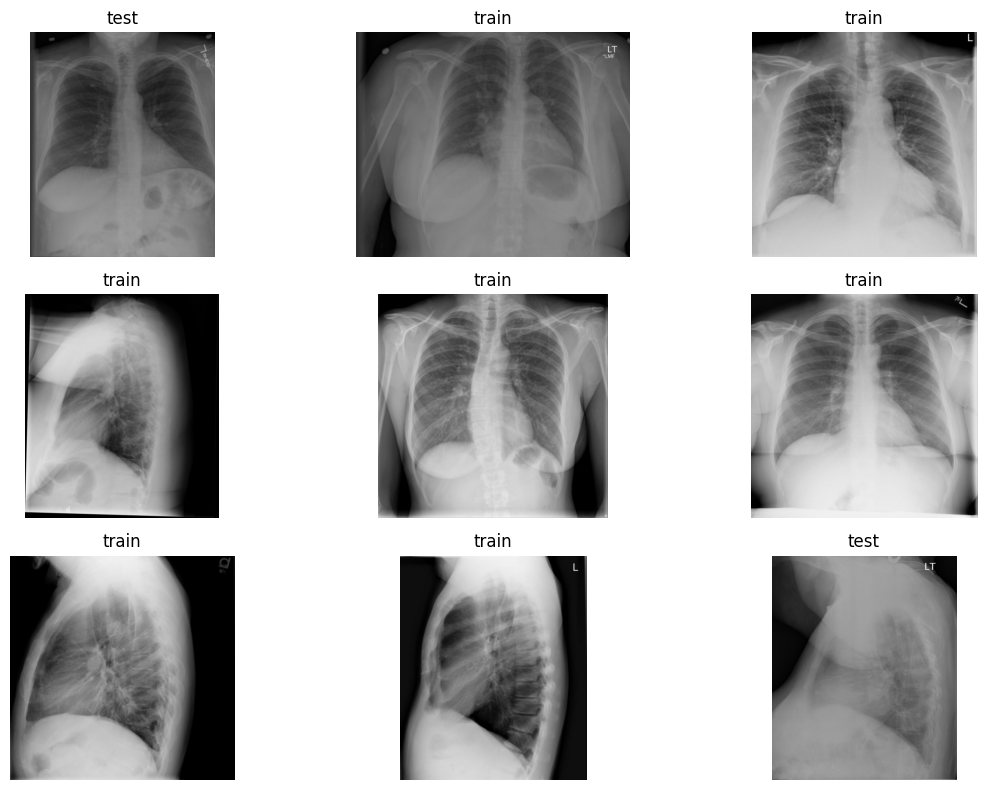

In [10]:

# Display a grid of some sampled images
plt.figure(figsize=(12, 8))
for idx, img_info in enumerate(sampled_images[:9]):
    plt.subplot(3, 3, idx + 1)
    img_path = os.path.join(IMAGE_DIR, img_info['path'])
    try:
        img = Image.open(img_path).convert('RGB')
        plt.imshow(img)
    except Exception as e:
        plt.text(0.5, 0.5, f"Error\n{e}", ha='center')
    plt.title(f"{img_info['split']}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [11]:
# Extract features
features_list = []
valid_indices = []

for i, img_info in enumerate(tqdm(sampled_images, desc="Extracting features")):
    full_path = os.path.join(IMAGE_DIR, img_info['path'])
    features = extract_features(full_path, transform)
    
    if features is not None:
        features_list.append(features)
        valid_indices.append(i)

features_array = np.array(features_list)
print(f"Features shape: {features_array.shape}")

Extracting features: 100%|██████████| 300/300 [01:35<00:00,  3.14it/s]

Features shape: (300, 512)


## 5. PCA Visualization

In [12]:
# Apply PCA to reduce dimensions
pca = PCA(n_components=2, random_state=42)
features_pca = pca.fit_transform(features_array)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Explained variance ratio: [0.2147399  0.07494166]
Total variance explained: 28.97%


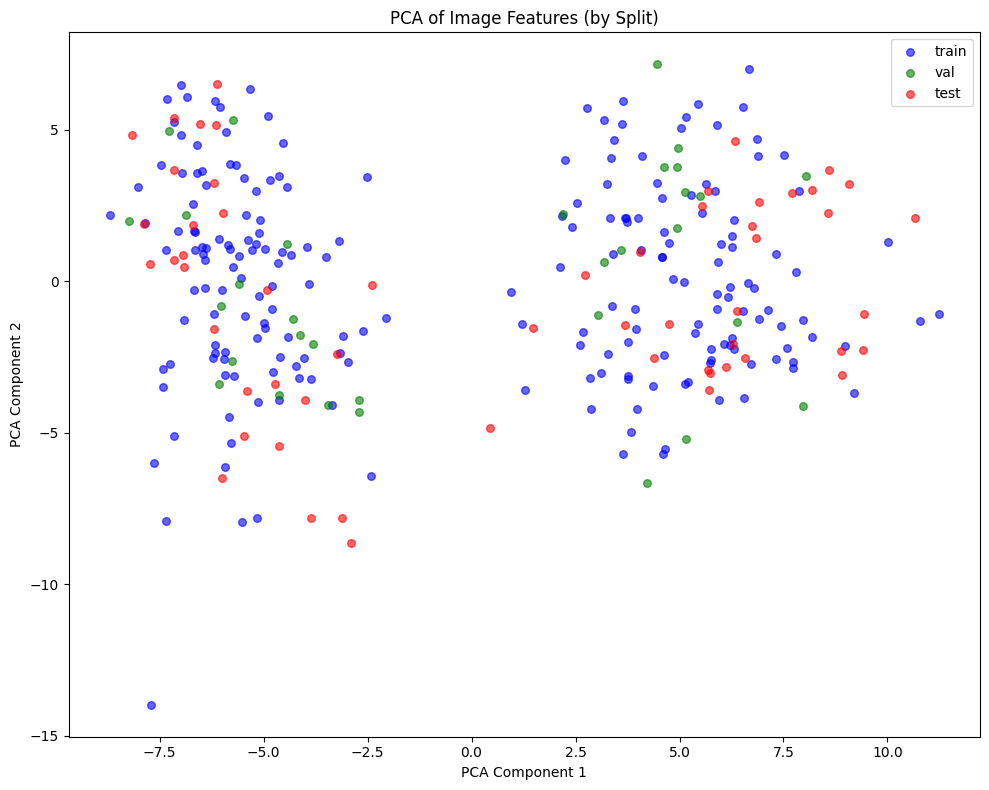

In [13]:
# Get labels for coloring
labels = [sampled_images[i]['split'] for i in valid_indices]
split_colors = {'train': 'blue', 'val': 'green', 'test': 'red'}

# Plot PCA results
plt.figure(figsize=(10, 8))

for split in ['train', 'val', 'test']:
    mask = [l == split for l in labels]
    plt.scatter(features_pca[mask, 0], features_pca[mask, 1], 
                c=split_colors[split], label=split, alpha=0.6, s=30)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of Image Features (by Split)')
plt.legend()
plt.tight_layout()
plt.show()

## 6. t-SNE Visualization

In [14]:
# Apply t-SNE for better visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
features_tsne = tsne.fit_transform(features_array)

print("t-SNE completed!")

t-SNE completed!


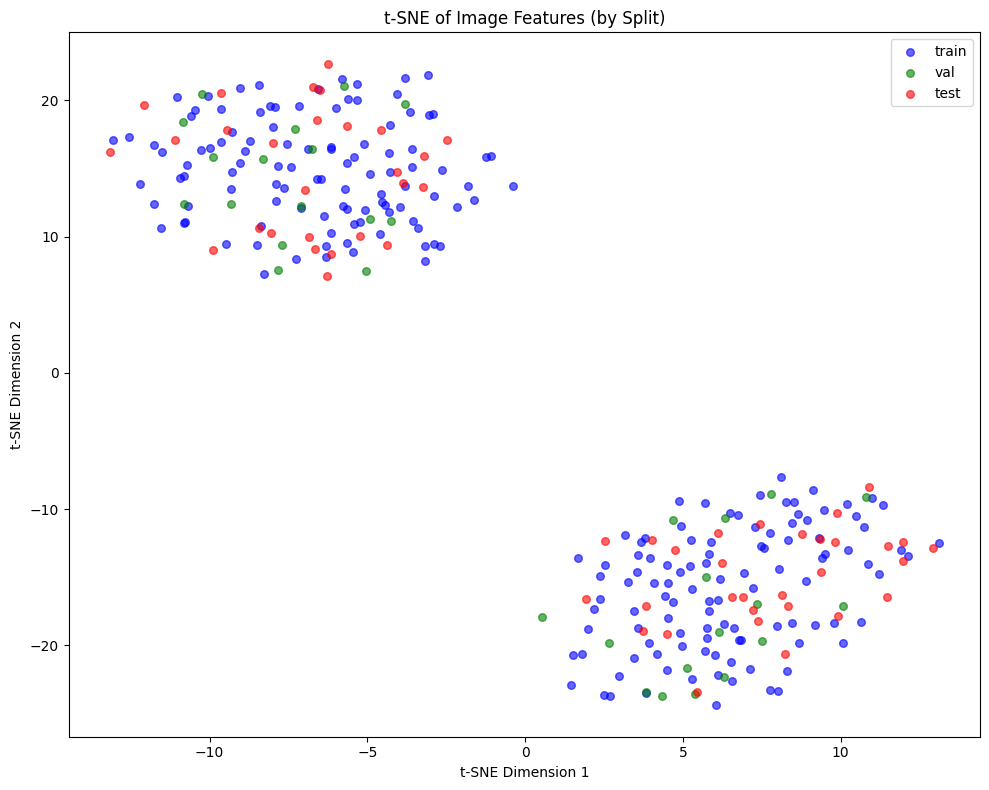

In [15]:
# Plot t-SNE results by split
plt.figure(figsize=(10, 8))

for split in ['train', 'val', 'test']:
    mask = [l == split for l in labels]
    plt.scatter(features_tsne[mask, 0], features_tsne[mask, 1], 
                c=split_colors[split], label=split, alpha=0.6, s=30)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE of Image Features (by Split)')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Disease-based Visualization

In [16]:
# Define disease keywords
diseases = [
    "atelectasis", "cardiomegaly", "consolidation", "edema",
    "effusion", "emphysema", "fibrosis", "hernia", "infiltration",
    "mass", "nodule", "pleural", "pneumonia", "pneumothorax"
]

# Assign disease labels to each image
disease_labels = []
for i in valid_indices:
    report = sampled_images[i]['report'].lower()
    found_diseases = [d for d in diseases if d in report]
    if len(found_diseases) > 0:
        disease_labels.append(found_diseases[0])  # Use first disease found
    else:
        disease_labels.append('normal')

# Get unique diseases
unique_diseases = list(set(disease_labels))
print(f"Unique disease categories: {unique_diseases}")

Unique disease categories: ['pleural', 'pneumothorax', 'atelectasis', 'normal', 'mass', 'effusion', 'emphysema', 'consolidation', 'cardiomegaly', 'edema', 'nodule']


C:\Users\DANG KHOA\AppData\Local\Temp\ipykernel_13608\1705049970.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_diseases))


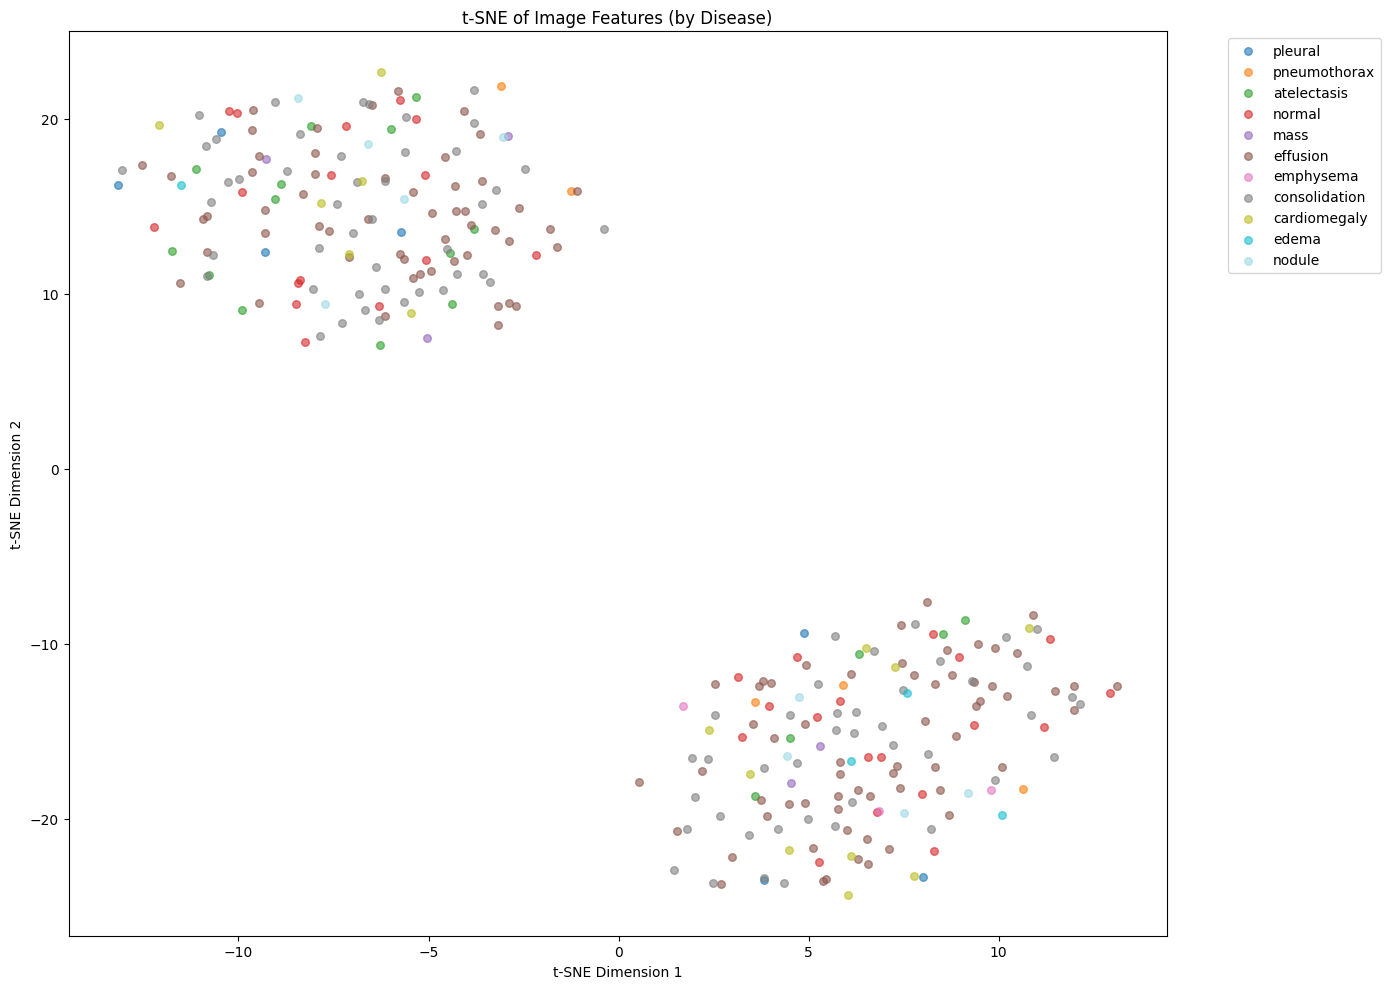

In [17]:
# Plot t-SNE by disease
plt.figure(figsize=(14, 10))

# Use colormap
cmap = plt.cm.get_cmap('tab20', len(unique_diseases))

for i, disease in enumerate(unique_diseases):
    mask = [d == disease for d in disease_labels]
    plt.scatter(features_tsne[mask, 0], features_tsne[mask, 1], 
                c=[cmap(i)], label=disease, alpha=0.6, s=30)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE of Image Features (by Disease)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Patch-level Feature Analysis

In [18]:
# Divide image into patches and extract features from each patch
def extract_patch_features(image_path, transform, patch_size=112, stride=56):
    """Extract features from image patches"""
    try:
        img = Image.open(image_path).convert('RGB')
        img_tensor = transform(img)
        
        # Get image dimensions
        _, h, w = img_tensor.shape
        
        patches = []
        patch_features = []
        
        for i in range(0, h - patch_size + 1, stride):
            for j in range(0, w - patch_size + 1, stride):
                patch = img_tensor[:, i:i+patch_size, j:j+patch_size]
                patches.append((i, j))
                
                with torch.no_grad():
                    feat = feature_extractor(patch.unsqueeze(0).to(device))
                patch_features.append(feat.squeeze().cpu().numpy())
        
        return np.array(patch_features), patches
    except Exception as e:
        print(f"Error: {e}")
        return None, None

# Sample a few images for patch analysis
sample_patches = sampled_images[:10]

all_patch_features = []
patch_positions = []

for img_info in tqdm(sample_patches, desc="Extracting patch features"):
    full_path = os.path.join(IMAGE_DIR, img_info['path'])
    patch_feats, positions = extract_patch_features(full_path, transform)
    
    if patch_feats is not None:
        all_patch_features.append(patch_feats)
        patch_positions.extend(positions)

all_patch_features = np.vstack(all_patch_features)
print(f"Total patch features: {all_patch_features.shape}")

Extracting patch features: 100%|██████████| 10/10 [00:00<00:00, 11.25it/s]

Total patch features: (90, 512)


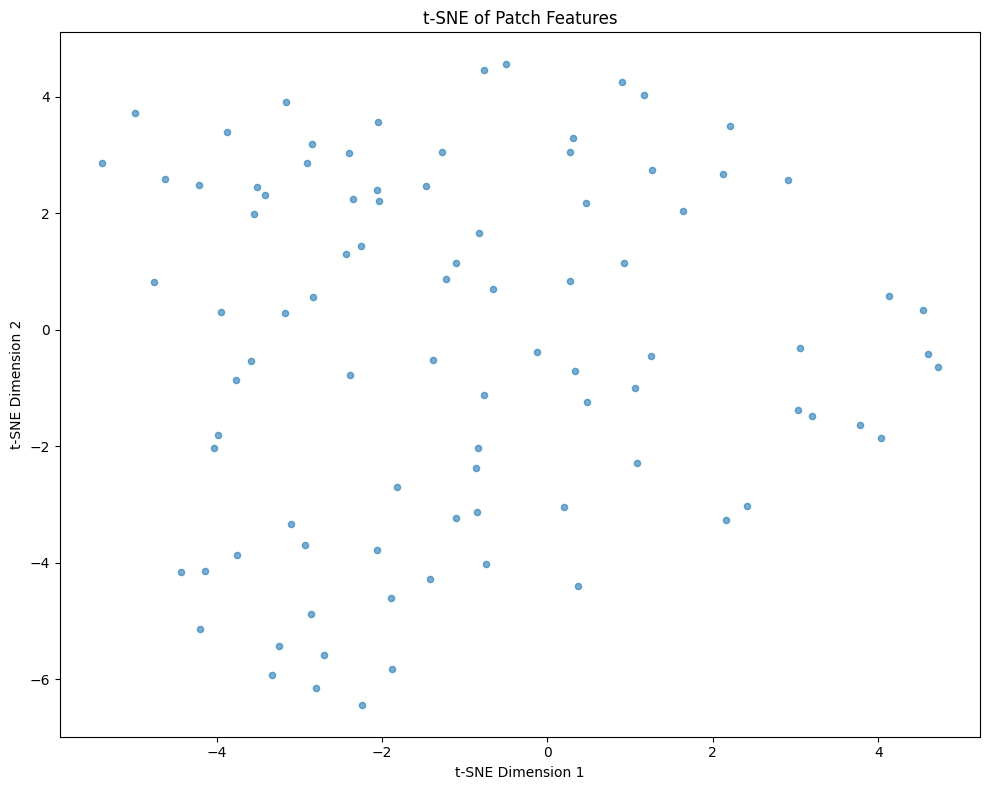

In [19]:
# Visualize patch feature clusters
tsne_patches = TSNE(n_components=2, random_state=42, perplexity=30)
patch_tsne = tsne_patches.fit_transform(all_patch_features)

plt.figure(figsize=(10, 8))
plt.scatter(patch_tsne[:, 0], patch_tsne[:, 1], alpha=0.6, s=20)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE of Patch Features')
plt.tight_layout()
plt.show()

## 9. Feature Statistics

Feature Statistics:
Mean: 0.9186
Std: 0.8510
Min: 0.0000
Max: 9.2426


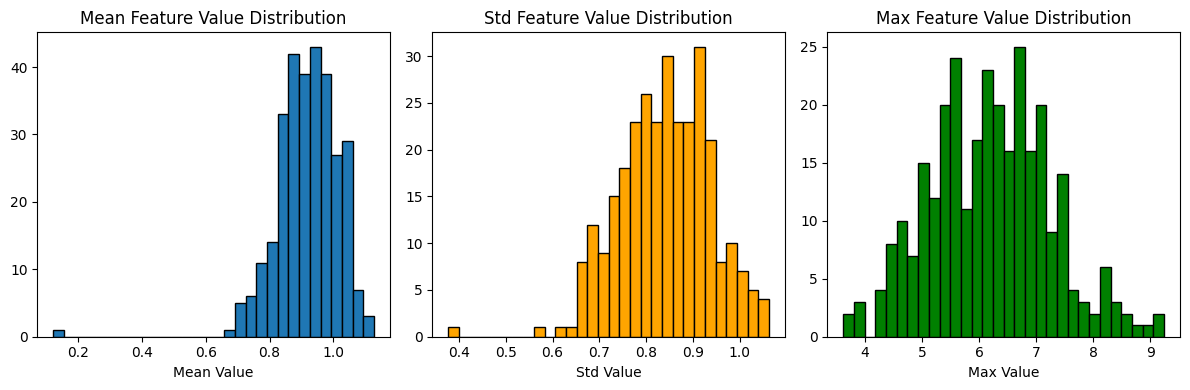

In [20]:
# Feature statistics
print("Feature Statistics:")
print(f"Mean: {features_array.mean():.4f}")
print(f"Std: {features_array.std():.4f}")
print(f"Min: {features_array.min():.4f}")
print(f"Max: {features_array.max():.4f}")

# Feature distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(features_array.mean(axis=1), bins=30, edgecolor='black')
plt.title('Mean Feature Value Distribution')
plt.xlabel('Mean Value')

plt.subplot(1, 3, 2)
plt.hist(features_array.std(axis=1), bins=30, edgecolor='black', color='orange')
plt.title('Std Feature Value Distribution')
plt.xlabel('Std Value')

plt.subplot(1, 3, 3)
plt.hist(features_array.max(axis=1), bins=30, edgecolor='black', color='green')
plt.title('Max Feature Value Distribution')
plt.xlabel('Max Value')

plt.tight_layout()
plt.show()

## 10. Summary

In [21]:
print("="*60)
print("PATCH FEATURE VISUALIZATION SUMMARY")
print("="*60)

print(f"\n📊 Dataset:")
print(f"   - Total images: {len(all_images)}")
print(f"   - Sampled images: {len(sampled_images)}")

print(f"\n🔍 Feature Extractor:")
print(f"   - Model: ResNet18 (pretrained)")
print(f"   - Feature dimension: {features_array.shape[1]}")

print(f"\n📈 Dimensionality Reduction:")
print(f"   - PCA variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")
   
print(f"\n🏷️ Disease Distribution:")
for disease in unique_diseases:
    count = disease_labels.count(disease)
    print(f"   - {disease}: {count} ({count/len(disease_labels)*100:.2f}%)")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)

PATCH FEATURE VISUALIZATION SUMMARY

📊 Dataset:
   - Total images: 5910
   - Sampled images: 300

🔍 Feature Extractor:
   - Model: ResNet18 (pretrained)
   - Feature dimension: 512

📈 Dimensionality Reduction:
   - PCA variance explained: 28.97%

🏷️ Disease Distribution:
   - pleural: 7 (2.33%)
   - pneumothorax: 5 (1.67%)
   - atelectasis: 18 (6.00%)
   - normal: 34 (11.33%)
   - mass: 5 (1.67%)
   - effusion: 114 (38.00%)
   - emphysema: 3 (1.00%)
   - consolidation: 86 (28.67%)
   - cardiomegaly: 15 (5.00%)
   - edema: 4 (1.33%)
   - nodule: 9 (3.00%)

ANALYSIS COMPLETE!
